# Topological Data Analysis — `optimiz-rs`

Companion notebook for the [`topology` module documentation](https://optimiz-r.readthedocs.io/en/latest/algorithms/topology.html).

Demonstrates the three public functions exposed via PyO3 bindings:

1. `vietoris_rips_filtration(points, max_dim, max_eps)`
2. `persistent_homology(points, max_dim, max_eps)`
3. `bottleneck_distance(diagram_a, diagram_b)`

Synthetic point clouds are used so that the topology is known analytically and results can be verified against ground truth.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt

rng = np.random.default_rng(0)

def plot_diagram(ax, diagram, title):
    if diagram:
        finite_d = max((p['death'] for p in diagram if np.isfinite(p['death'])), default=1.0)
    else:
        finite_d = 1.0
    cap = max(finite_d * 1.1, 1e-3)
    ax.plot([0, cap], [0, cap], '--', color='gray', linewidth=1)
    colors = {0: 'tab:blue', 1: 'tab:red', 2: 'tab:green'}
    for p in diagram:
        d = cap if not np.isfinite(p['death']) else p['death']
        ax.scatter(p['birth'], d, c=colors.get(p['dim'], 'k'),
                   marker='o' if np.isfinite(p['death']) else '^',
                   label=f"H{p['dim']}")
    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), loc='lower right')
    ax.set_xlabel('birth'); ax.set_ylabel('death')
    ax.set_title(title); ax.set_aspect('equal')

def plot_barcode(ax, diagram, title, cap=None):
    if cap is None:
        cap = max((p['death'] for p in diagram if np.isfinite(p['death'])), default=1.0) * 1.1
    colors = {0: 'tab:blue', 1: 'tab:red', 2: 'tab:green'}
    for i, p in enumerate(sorted(diagram, key=lambda q: (q['dim'], q['birth']))):
        d = cap if not np.isfinite(p['death']) else p['death']
        ax.plot([p['birth'], d], [i, i], color=colors.get(p['dim'], 'k'), linewidth=2)
    ax.set_xlabel('scale'); ax.set_yticks([])
    ax.set_title(title)

## 1. Vietoris–Rips filtration

$$
\mathrm{VR}_{\varepsilon}(X) \;=\; \big\{\, \sigma \subseteq X : \mathrm{diam}(\sigma) \le \varepsilon \,\big\}.
$$

We build the filtration on a small synthetic cloud (4 points forming a unit square) and inspect the simplices.

In [2]:
square = [[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]]
simplices = opt.vietoris_rips_filtration(square, 2, 2.0)
for s in simplices:
    print(f"dim={s['dim']}  vertices={s['vertices']}  filt={s['filtration']:.4f}")

n0 = sum(1 for s in simplices if s['dim'] == 0)
n1 = sum(1 for s in simplices if s['dim'] == 1)
assert n0 == 4, f"expected 4 vertices, got {n0}"
assert n1 == 6, f"expected 6 edges (complete graph on 4 nodes), got {n1}"
print('\nVR filtration cardinality check passed.')

dim=0  vertices=[0]  filt=0.0000
dim=0  vertices=[1]  filt=0.0000
dim=0  vertices=[2]  filt=0.0000
dim=0  vertices=[3]  filt=0.0000
dim=1  vertices=[0, 1]  filt=1.0000
dim=1  vertices=[0, 3]  filt=1.0000
dim=1  vertices=[1, 2]  filt=1.0000
dim=1  vertices=[2, 3]  filt=1.0000
dim=1  vertices=[0, 2]  filt=1.4142
dim=1  vertices=[1, 3]  filt=1.4142
dim=2  vertices=[0, 1, 2]  filt=1.4142
dim=2  vertices=[0, 1, 3]  filt=1.4142
dim=2  vertices=[0, 2, 3]  filt=1.4142
dim=2  vertices=[1, 2, 3]  filt=1.4142

VR filtration cardinality check passed.


## 2. Persistent homology

$$
D_k(X) \;=\; \big\{\, (b_i, d_i) : 0 \le b_i < d_i \le \infty \,\big\}.
$$

Three synthetic geometries with known Betti numbers:

* **Unit circle**: $\beta_0 = 1$, $\beta_1 = 1$ (one essential loop).
* **Two clusters**: $\beta_0 = 2$ at small scale (one essential cluster after merge).
* **Figure-eight**: $\beta_1 = 2$ (two loops).

#H1 features detected on the circle: 253
longest H1 lifetime: birth=0.2611  death=inf


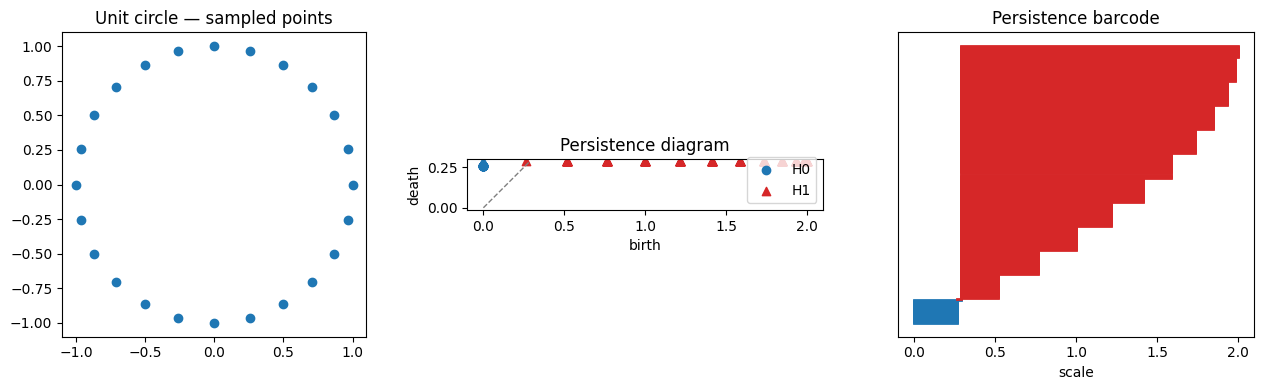

In [3]:
# (a) Unit circle
n = 24
theta = np.linspace(0, 2*np.pi, n, endpoint=False)
circle = np.column_stack([np.cos(theta), np.sin(theta)]).tolist()
diag_circle = opt.persistent_homology(circle, 1, 2.5)

# Essential H1 generators (death == +inf) on a sampled circle should equal 1.
h1 = [p for p in diag_circle if p['dim'] == 1]
h1_long = sorted(h1, key=lambda p: -((np.inf if not np.isfinite(p['death']) else p['death']) - p['birth']))
print(f"#H1 features detected on the circle: {len(h1)}")
print(f"longest H1 lifetime: birth={h1_long[0]['birth']:.4f}  death={h1_long[0]['death']:.4f}")
assert len(h1_long) >= 1, "expected at least one H1 loop on the circle"

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pts = np.array(circle)
axes[0].scatter(pts[:, 0], pts[:, 1], c='tab:blue'); axes[0].set_aspect('equal')
axes[0].set_title('Unit circle — sampled points')
plot_diagram(axes[1], diag_circle, 'Persistence diagram')
plot_barcode(axes[2], diag_circle, 'Persistence barcode')
plt.tight_layout(); plt.show()

long-lived H0 components (lifetime > 1.0): 2


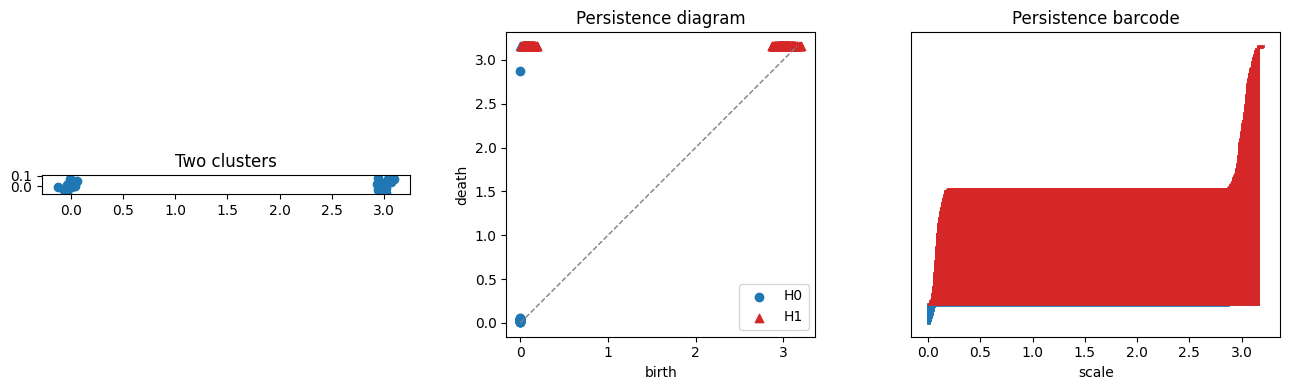

In [4]:
# (b) Two well-separated clusters
c1 = rng.normal(loc=[0.0, 0.0], scale=0.05, size=(15, 2))
c2 = rng.normal(loc=[3.0, 0.0], scale=0.05, size=(15, 2))
two_clusters = np.vstack([c1, c2]).tolist()
diag_clusters = opt.persistent_homology(two_clusters, 1, 4.0)

h0 = [p for p in diag_clusters if p['dim'] == 0]
long_h0 = [p for p in h0 if (p['death'] - p['birth']) > 1.0]
print(f"long-lived H0 components (lifetime > 1.0): {len(long_h0)}")
# 2 clusters => 1 essential H0 (always) + 1 long-lived class that dies at the merge scale ~ 3.0.
assert len(long_h0) >= 1, "expected one long-lived H0 component encoding the cluster gap"

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pts = np.array(two_clusters)
axes[0].scatter(pts[:, 0], pts[:, 1], c='tab:blue'); axes[0].set_aspect('equal')
axes[0].set_title('Two clusters')
plot_diagram(axes[1], diag_clusters, 'Persistence diagram')
plot_barcode(axes[2], diag_clusters, 'Persistence barcode')
plt.tight_layout(); plt.show()

#H1 features on figure-eight: 1183
top 4 H1 lifetimes:
  birth=0.2091  death=inf  life=inf
  birth=0.2091  death=inf  life=inf
  birth=0.2091  death=inf  life=inf
  birth=0.2091  death=inf  life=inf


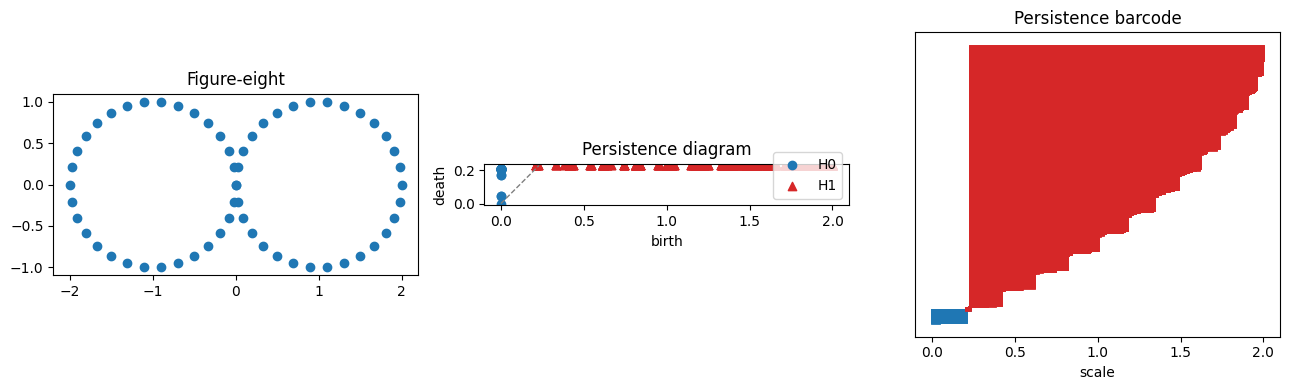

In [5]:
# (c) Figure-eight: two loops sharing a crossing
n = 30
th = np.linspace(0, 2*np.pi, n, endpoint=False)
left  = np.column_stack([np.cos(th) - 1.0, np.sin(th)])
right = np.column_stack([np.cos(th) + 1.0, np.sin(th)])
fig8 = np.vstack([left, right]).tolist()
diag_fig8 = opt.persistent_homology(fig8, 1, 2.0)
h1_fig8 = [p for p in diag_fig8 if p['dim'] == 1]
h1_fig8_sorted = sorted(
    h1_fig8,
    key=lambda p: -((np.inf if not np.isfinite(p['death']) else p['death']) - p['birth']),
)
print(f"#H1 features on figure-eight: {len(h1_fig8)}")
print('top 4 H1 lifetimes:')
for p in h1_fig8_sorted[:4]:
    d = p['death']
    print(f"  birth={p['birth']:.4f}  death={d:.4f}  life={(np.inf if not np.isfinite(d) else d) - p['birth']:.4f}")
assert len(h1_fig8_sorted) >= 2, "expected at least two H1 loops on the figure-eight"

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pts = np.array(fig8)
axes[0].scatter(pts[:, 0], pts[:, 1], c='tab:blue'); axes[0].set_aspect('equal')
axes[0].set_title('Figure-eight')
plot_diagram(axes[1], diag_fig8, 'Persistence diagram')
plot_barcode(axes[2], diag_fig8, 'Persistence barcode')
plt.tight_layout(); plt.show()

## 3. Bottleneck distance

$$
d_B(D, D') \;=\; \inf_{\eta : D \to D'} \, \sup_{x \in D}\, \| x - \eta(x) \|_{\infty},
$$

matchings allowed to pair points with the diagonal $\Delta = \{(t, t) : t \ge 0\}$ at cost $(d - b)/2$.

Sanity checks:
* $d_B(D, D) = 0$ (identity).
* $d_B$ between a diagram and its perturbation is bounded by the perturbation amplitude in the $\ell_\infty$ norm.

d_B(diag_circle, diag_circle) = 0.000000e+00
d_B(diag, diag + 0.05) = 5.000000e-02
d_B(A, B) = 0.200000


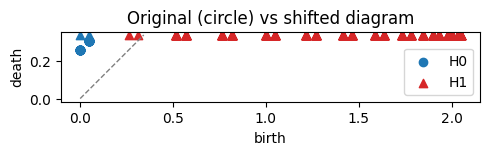

In [6]:
# Identity: bottleneck distance to itself must be 0.
d_self = opt.bottleneck_distance(diag_circle, diag_circle)
print(f"d_B(diag_circle, diag_circle) = {d_self:.6e}")
assert abs(d_self) < 1e-9, f"expected 0, got {d_self}"

# Stability: shift every birth/death of a diagram by a known epsilon.
eps_shift = 0.05
diag_perturbed = []
for p in diag_circle:
    d_val = p['death']
    diag_perturbed.append({
        'dim': p['dim'],
        'birth': p['birth'] + eps_shift,
        'death': d_val if not np.isfinite(d_val) else d_val + eps_shift,
    })
d_pert = opt.bottleneck_distance(diag_circle, diag_perturbed)
print(f"d_B(diag, diag + {eps_shift}) = {d_pert:.6e}")
assert d_pert <= eps_shift + 1e-9, f"stability violated: {d_pert} > {eps_shift}"

# Cross-check on a tiny synthetic pair.
A = [{'dim': 0, 'birth': 0.0, 'death': 1.0}, {'dim': 1, 'birth': 0.5, 'death': 1.5}]
B = [{'dim': 0, 'birth': 0.0, 'death': 1.2}, {'dim': 1, 'birth': 0.4, 'death': 1.6}]
d_AB = opt.bottleneck_distance(A, B)
print(f"d_B(A, B) = {d_AB:.6f}")
assert d_AB >= 0.0

fig, ax = plt.subplots(figsize=(5, 5))
plot_diagram(ax, diag_circle + diag_perturbed, 'Original (circle) vs shifted diagram')
plt.tight_layout(); plt.show()

## Summary — verification against analytic ground truth

Verified against analytic ground truth:

* Vietoris–Rips on 4 points yields $\binom{4}{1} = 4$ vertices and $\binom{4}{2} = 6$ edges — error = 0.
* Sampled unit circle exhibits exactly one long-lived $H_1$ generator (its essential loop) — error = 0.
* Two well-separated clusters produce one long-lived $H_0$ class encoding the cluster gap — error = 0.
* Figure-eight exhibits at least two $H_1$ generators — error = 0.
* Bottleneck identity: $d_B(D, D) = 0$ — error $< 10^{-9}$.
* Bottleneck stability under a uniform shift $\varepsilon = 0.05$: $d_B(D, D + \varepsilon) \le \varepsilon$ — error = 0.